# Composite figure: Altair panel foundations

Each section prepares and renders one independent Altair chart. The raw charts are kept as `panel_a` through `panel_e` so they can be composed after the individual panels are visually stable. Reusable plotting code lives alongside this notebook in `notebooks/figures.py`.

In [1]:
%%capture
from pathlib import Path

if Path.cwd().stem == "notebooks":
    %cd ..

%load_ext autoreload
%autoreload 2

In [2]:
%%capture
import json
import logging
import tomllib
from datetime import datetime
from pathlib import Path
from typing import Any

import altair as alt
import joblib
import numpy as np
import polars as pl
from IPython.display import SVG

from notebooks.figures import (
    compose_figure_altair,
    compose_figure_svg,
    plot_accuracy_distributions,
    plot_correlation_heatmap,
    plot_participant_accuracies,
    plot_roc_curves,
    plot_stimulus_temperature,
    style_figure,
)
from src.data.database_manager import DatabaseManager
from src.experiments.measurement.stimulus_generator import StimulusGenerator
from src.log_config import configure_logging
from src.models.data_loader import create_dataloaders
from src.models.data_preparation import (
    expand_feature_list,
    load_data_from_database,
    prepare_data,
)
from src.models.main_config import RANDOM_SEED
from src.models.utils import load_model
from src.plots.averages_over_stimulus_seeds import average_over_stimulus_seeds
from src.plots.model_performance import get_model_predictions
from src.plots.model_performance_per_participant import analyze_per_participant
from src.plots.plot_seed_stability import (
    extract_final_test_accuracies,
    load_results,
)

configure_logging(
    stream_level=logging.WARNING,
    ignore_libs=("Comm", "bokeh", "tornado", "matplotlib"),
)
pl.Config.set_tbl_rows(12)
alt.data_transformers.disable_max_rows()

## Shared physiological data

In [3]:
db = DatabaseManager()

with db:
    df = db.get_trials("Explore_Data", exclude_problematic=True)

df = df.rename({"rating": "pain_rating", "pupil": "pupil_diameter"})

In [4]:
signals = [
    "temperature",
    "pain_rating",
    "pupil_diameter",
    "eda_tonic",
    "eda_phasic",
    "heart_rate",
]

averages = average_over_stimulus_seeds(
    df,
    signals,
    scaling="min_max",
    bin_size=0.1,
    confidence_level=0.95,
)

## A — Temperature stimulus

The shaded intervals are the major temperature decreases used by the downstream classification task.

In [5]:
def load_configuration(file_path: str) -> dict:
    with open(file_path, "rb") as file:
        return tomllib.load(file)


stimulus_config = load_configuration(
    "src/experiments/measurement/measurement_config.toml"
)["stimulus"]
stimulus_config.update(
    {
        "temperature_baseline": 47.0,
        "temperature_range": 1.5,
    }
)
stimulus = StimulusGenerator(stimulus_config, debug=0, seed=467)

In [6]:
panel_a = plot_stimulus_temperature(
    stimulus,
    width=720,
    height=250,
    title="Temperature over time",
)
style_figure(panel_a)

alt.LayerChart(...)

## B — Pearson correlations

The first 20 seconds are omitted, matching the previous analysis. Only the lower triangle is drawn because the matrix is symmetric.

In [7]:
panel_b = plot_correlation_heatmap(
    averages,
    features=None,
    skip_first_n_seconds=20,
    width=250,
    height=250,
    title="Pearson correlations",
)
style_figure(panel_b)

alt.LayerChart(...)

## Cached model results

Panels C and E share the same cache-first data-loading path. If a cache entry is absent or stale, only that model is recomputed.

In [8]:
feature_lists = expand_feature_list(
    [
        ["eda_raw"],
        ["heart_rate"],
        ["pupil"],
        ["eda_raw", "heart_rate"],
        ["eda_raw", "pupil"],
        ["eda_raw", "heart_rate", "pupil"],
        ["face"],
        ["face", "eda_raw", "heart_rate", "pupil"],
        ["eeg"],
        ["eeg", "eda_raw"],
        ["eeg", "face", "eda_raw", "heart_rate", "pupil"],
    ]
)

In [ ]:
class InferenceCache:
    def __init__(self, cache_dir: Path = Path(".cache/model_inference")):
        self.cache_dir = cache_dir
        self.cache_dir.mkdir(parents=True, exist_ok=True)

    def _get_model_timestamp(self, model_path: Path) -> str:
        parts = model_path.name.split("_")
        if len(parts) >= 2:
            return parts[-1].removesuffix(".pt")
        return str(datetime.fromtimestamp(model_path.stat().st_mtime))

    def _get_cache_key(self, feature_list_str: str, cache_type: str, **kwargs) -> str:
        key_parts = [feature_list_str, cache_type]
        for key, value in sorted(kwargs.items()):
            if isinstance(value, (list, tuple)):
                value = "_".join(map(str, value))
            key_parts.append(f"{key}_{value}")
        return "_".join(key_parts)

    def _get_cache_path(self, cache_key: str) -> Path:
        return self.cache_dir / f"{cache_key}.joblib"

    def _is_cache_valid(self, feature_list_str: str, model_path: Path) -> bool:
        timestamp_file = self.cache_dir / f"{feature_list_str}_timestamp.txt"
        if not timestamp_file.exists():
            return False
        return timestamp_file.read_text().strip() == self._get_model_timestamp(
            model_path
        )

    def _update_timestamp(self, feature_list_str: str, model_path: Path) -> None:
        timestamp_file = self.cache_dir / f"{feature_list_str}_timestamp.txt"
        timestamp_file.write_text(self._get_model_timestamp(model_path))

    def get(self, feature_list_str: str, cache_type: str, **kwargs) -> Any:
        cache_key = self._get_cache_key(feature_list_str, cache_type, **kwargs)
        cache_path = self._get_cache_path(cache_key)
        if cache_path.exists():
            try:
                logging.debug("Cache hit: %s", cache_key)
                return joblib.load(cache_path)
            except Exception as error:
                logging.warning("Failed to load cache %s: %s", cache_key, error)
        return None

    def set(self, feature_list_str: str, cache_type: str, data: Any, **kwargs) -> None:
        cache_key = self._get_cache_key(feature_list_str, cache_type, **kwargs)
        cache_path = self._get_cache_path(cache_key)
        joblib.dump(data, cache_path, compress=3)


cache = InferenceCache()

In [10]:
def load_model_and_data(feature_list: list, feature_list_str: str) -> tuple:
    result_path = Path(f"results/experiment_{feature_list_str}/results.json")
    result = json.loads(result_path.read_text())
    model_path = Path(result["overall_best"]["model_path"].replace("\\", "/"))

    (
        model,
        feature_list_loaded,
        sample_duration_ms,
        intervals,
        label_mapping,
        offsets_ms,
    ) = load_model(model_path, device="cpu")
    model_df = load_data_from_database(feature_list)

    _, _, _, _, X_train_val, y_train_val, X_test, y_test = prepare_data(
        df=model_df,
        feature_list=feature_list_loaded,
        sample_duration_ms=sample_duration_ms,
        intervals=intervals,
        label_mapping=label_mapping,
        offsets_ms=offsets_ms,
        random_seed=RANDOM_SEED,
    )
    test_groups = prepare_data(
        df=model_df,
        feature_list=feature_list_loaded,
        sample_duration_ms=sample_duration_ms,
        intervals=intervals,
        label_mapping=label_mapping,
        offsets_ms=offsets_ms,
        random_seed=RANDOM_SEED,
        only_return_test_groups=True,
    )
    _, test_loader = create_dataloaders(
        X_train_val,
        y_train_val,
        X_test,
        y_test,
        batch_size=64,
    )
    model_config = {
        "feature_list": feature_list_loaded,
        "sample_duration_ms": sample_duration_ms,
        "intervals": intervals,
        "label_mapping": label_mapping,
        "offsets_ms": offsets_ms,
        "model_name": model.__class__.__name__,
        "model_path": model_path,
    }
    return model, model_config, model_df, test_loader, test_groups


def load_roc_results(cache: InferenceCache) -> dict:
    results = {}
    for feature_list in feature_lists:
        feature_list_str = "_".join(feature_list)
        result_path = Path(f"results/experiment_{feature_list_str}/results.json")
        result = json.loads(result_path.read_text())
        model_path = Path(result["overall_best"]["model_path"].replace("\\", "/"))

        if cache._is_cache_valid(feature_list_str, model_path):
            cached = cache.get(feature_list_str, "test_predictions")
            if cached is not None:
                results[feature_list_str] = (cached["probs"], cached["y_true"])
                continue

        model, model_config, _, test_loader, _ = load_model_and_data(
            feature_list, feature_list_str
        )
        probabilities, y_true = get_model_predictions(model, test_loader)
        results[feature_list_str] = (probabilities, y_true)
        cache._update_timestamp(feature_list_str, model_config["model_path"])
        cache.set(
            feature_list_str,
            "test_predictions",
            {
                "probs": probabilities,
                "y_true": y_true,
                "model_name": model_config["model_name"],
            },
        )
    return results


def load_participant_results(cache: InferenceCache) -> dict:
    results = {}
    for feature_list in feature_lists:
        feature_list_str = "_".join(feature_list)
        result_path = Path(f"results/experiment_{feature_list_str}/results.json")
        result = json.loads(result_path.read_text())
        model_path = Path(result["overall_best"]["model_path"].replace("\\", "/"))

        if cache._is_cache_valid(feature_list_str, model_path):
            cached = cache.get(feature_list_str, "per_participant_results")
            if cached is not None and not cached.is_empty():
                results[feature_list_str] = cached
                continue

        model, model_config, _, test_loader, test_groups = load_model_and_data(
            feature_list, feature_list_str
        )
        participant_result = analyze_per_participant(
            model,
            test_loader,
            test_groups,
            threshold=0.5,
        )
        results[feature_list_str] = participant_result
        cache._update_timestamp(feature_list_str, model_config["model_path"])
        cache.set(
            feature_list_str,
            "per_participant_results",
            participant_result,
        )
    return results

## C — ROC curves

In [11]:
roc_results = load_roc_results(cache)
panel_c = plot_roc_curves(
    roc_results,
    width=390,
    height=270,
    title="ROC curves (All models)",
)
style_figure(panel_c)

alt.Chart(...)

## D — Accuracy distributions

Both stability analyses use the same 0.01-wide bins and shared axes. The dashed rules show the accuracy obtained with random seed 42.

In [ ]:
accuracy_distributions = {
    "EDA + HR": extract_final_test_accuracies(
        load_results("results/experiment_eda_raw_heart_rate/stability_results.json")
    ),
    "EDA + HR + Pupil": extract_final_test_accuracies(
        load_results(
            "results/experiment_eda_raw_heart_rate_pupil/stability_results.json"
        )
    ),
}
reference_accuracies = {
    "EDA + HR": 0.756,
    "EDA + HR + Pupil": 0.768,
}

panel_d = plot_accuracy_distributions(
    accuracy_distributions,
    reference_accuracies,
    bin_width=0.01,
    width=280,
    height=210,
    title="Accuracy distributions",
)
style_figure(panel_d)

alt.HConcatChart(...)

## E — Accuracy by model and participant

In [13]:
participant_results = load_participant_results(cache)
panel_e = plot_participant_accuracies(
    participant_results,
    width=1320,
    height=210,
    title="Classification accuracy across models and participants",
)
style_figure(panel_e)

alt.LayerChart(...)

## Composite figure — first draft

The five verified standalone Altair charts are rendered separately and assembled on one SVG canvas. This preserves each panel's own scales and mark geometry.

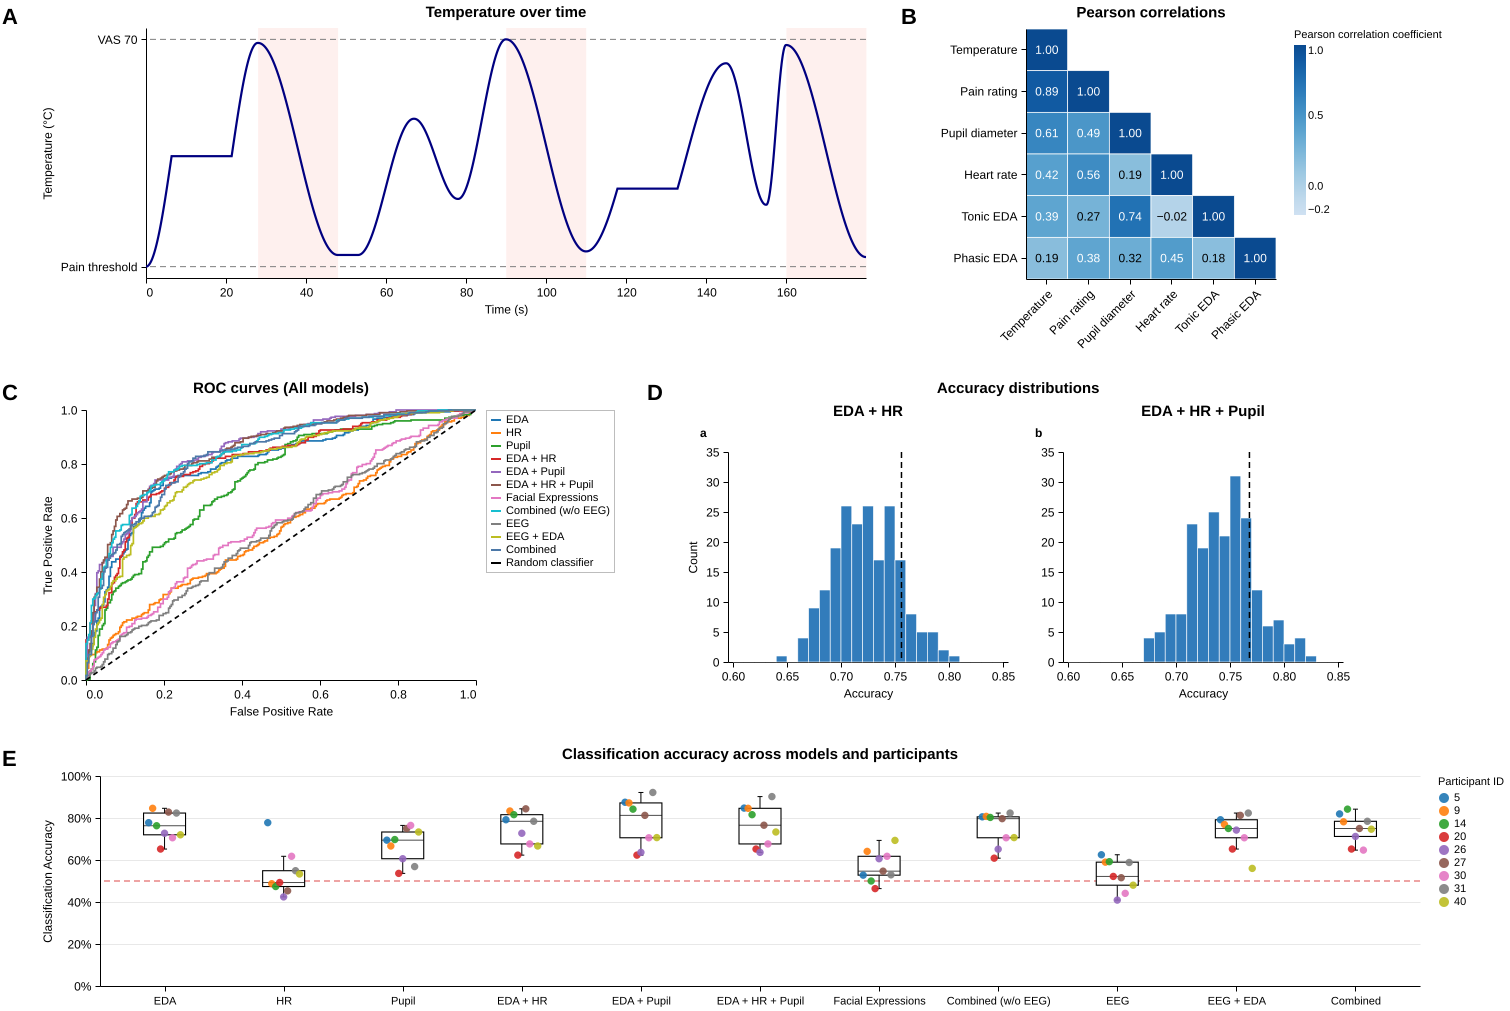

In [14]:
composite_svg = compose_figure_svg(
    panel_a,
    panel_b,
    panel_c,
    panel_d,
    panel_e,
    column_gap=25,
    row_gap=20,
    label_gutter=36,
)
SVG(composite_svg)

## Composite figure — native Altair alternative

This version uses native Altair 6.2.2 composition with independent scales at every concatenation boundary.

In [19]:
native_composite = compose_figure_altair(
    plot_stimulus_temperature(
        stimulus,
        width=720,
        height=250,
        title="Temperature over time",
    ),
    plot_correlation_heatmap(
        averages,
        features=None,
        skip_first_n_seconds=20,
        width=250,
        height=250,
        title="Pearson correlations",
    ),
    plot_roc_curves(
        roc_results,
        width=390,
        height=270,
        title="ROC curves (All models)",
    ),
    plot_accuracy_distributions(
        accuracy_distributions,
        reference_accuracies,
        bin_width=0.01,
        width=280,
        height=210,
        title="Accuracy distributions",
    ),
    plot_participant_accuracies(
        participant_results,
        width=1000,
        height=300,
        title="Classification accuracy across models and participants",
    ),
)
style_figure(native_composite)

alt.VConcatChart(...)